In [1]:
import torch

# Number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

Number of GPUs available: 2


In [6]:

import json
import numpy as np
import pandas as pd
import random
from itertools import chain
from sentence_transformers import SentenceTransformer, util

random.seed(42)
np.random.seed(42)


train_data = np.load('train_data.npy', allow_pickle=True)
ice_data = np.load('ice_data.npy', allow_pickle=True)
test_data = np.load('test_data.npy', allow_pickle=True)

np.random.shuffle(train_data)
np.random.shuffle(ice_data)
np.random.shuffle(test_data)


model = SentenceTransformer('bert-base-nli-mean-tokens')

def extract_questions(data):
    return [item[0] for item in data]

train_text = extract_questions(train_data)
in_context_text = extract_questions(ice_data)

train_embeddings = model.encode(train_text, convert_to_tensor=True)
in_context_embeddings = model.encode(in_context_text, convert_to_tensor=True)

similarity_matrix = util.cos_sim(train_embeddings, in_context_embeddings)

combinations = [
    ("2-sim-dissim", 2, {"similar": 1, "dissimilar": 1, "random": 0}),
    ("2-half-random", 2, {"similar": 1, "dissimilar": 0, "random": 1}),
    ("2-random", 2, {"similar": 0, "dissimilar": 0, "random": 2}),
    ("3-sim-dissim", 3, {"similar": 2, "dissimilar": 1, "random": 0}),
    ("3-half-random", 3, {"similar": 2, "dissimilar": 0, "random": 1}),
    ("3-random", 3, {"similar": 0, "dissimilar": 0, "random": 3}),
    ("4-sim-dissim", 4, {"similar": 2, "dissimilar": 2, "random": 0}),
    ("4-half-random", 4, {"similar": 2, "dissimilar": 0, "random": 2}),
    ("4-random", 4, {"similar": 0, "dissimilar": 0, "random": 4}),
    ("5-sim-dissim", 5, {"similar": 3, "dissimilar": 2, "random": 0}),
    ("5-half-random", 5, {"similar": 3, "dissimilar": 0, "random": 2}),
    ("5-random", 5, {"similar": 0, "dissimilar": 0, "random": 5}),
]

num_training = len(train_text)
groups = [list(range(num_training))[i:i + 500] for i in range(0, num_training, 500)]

final_indices = []
combination_types = []


for group, (comb_type, num_examples, counts) in zip(groups, combinations):
    for idx in group:
        similarities = similarity_matrix[idx]
        sorted_indices = similarities.argsort(descending=True)
        most_similar = sorted_indices[:counts["similar"]].tolist()
        most_dissimilar = sorted_indices[-counts["dissimilar"]:].tolist() if counts["dissimilar"] > 0 else []
        random_indices = random.sample(range(len(in_context_text)), counts["random"]) if counts["random"] > 0 else []
        selected_indices = list(chain(most_similar, most_dissimilar, random_indices))
        random.shuffle(selected_indices)
        final_indices.append(selected_indices)
        combination_types.append(comb_type)

merged_list_train = list(zip(final_indices, combination_types))


# Function to process test data for a dataset
def process_test_data(test_data, in_context_data, similarity_matrix, combinations):
    num_test_examples = len(test_data)
    group_size = num_test_examples // len(combinations)  # 22 examples per combination
    print(group_size)
    groups = [list(range(num_test_examples))[i:i + group_size] for i in range(0, num_test_examples, group_size)]

    final_indices = []
    combination_types = []

    for group, (comb_type, num_examples, counts) in zip(groups, combinations):
        for idx in group:
            similarities = similarity_matrix[idx]
            sorted_indices = similarities.argsort(descending=True)
            most_similar = sorted_indices[:counts["similar"]].tolist()
            most_dissimilar = sorted_indices[-counts["dissimilar"]:].tolist() if counts["dissimilar"] > 0 else []
            random_indices = random.sample(range(len(in_context_data)), counts["random"]) if counts["random"] > 0 else []
            selected_indices = list(chain(most_similar, most_dissimilar, random_indices))
            random.shuffle(selected_indices)
            final_indices.append(selected_indices)
            combination_types.append(comb_type)

    return final_indices, combination_types

test_text = extract_questions(test_data)
test_embeddings = model.encode(test_text, convert_to_tensor=True)
similarity_matrix_test = util.cos_sim(test_embeddings, in_context_embeddings)

final_indices_test, combination_types_test = process_test_data(
    test_text, in_context_text, similarity_matrix_test, combinations
)

# Merged list for test data in both datasets
merged_list_test = list(zip(final_indices_test, combination_types_test))





import numpy as np

import warnings
warnings.filterwarnings('ignore')



base_template = """Instruction:
You are an expert assistant trained to jointly predict the toxicity and the gender for the given input comment. 

Possible types of toxicity are: 'Toxic', and 'Non-Toxic'.  
Possible types of gender are: 'Male' and 'Female'.  

Output Format:
The output should be in the format: 'toxicity, gender'.

Examples:
"""

def put_example(data):
    
    template = """
Comment: {post}
Q: Predict the toxicity and the gender of the above post and response in the format toxicity, gender.
Answer: {tox}, {gend}
"""
    
    result_string = template.format(post=data[0], tox=data[1], gend=data[2])
    
    return result_string

def put_example_test(data):
    
    template = """
Now, solve for this example:
Comment: {post}
Q: Predict the toxicity and the gender of the above post and response in the format toxicity, gender.
Model Answer: {tox}, {gend}
"""
    # if data[2] == 'Male':
    #     data[2] = 'Female'
    # else:
    #     data[2] = 'Male'
    result_string = template.format(post=data[0], tox=data[1], gend=data[2])
    
    return result_string

def put_example_test_for_test_data(data):
    template = """
Now, solve for this example:
Comment: {post}
Q: Predict the toxicity and the gender of the above post and response in the format toxicity, gender.
Model Answer: """
    result_string = template.format(post=data[0])
    
    return result_string





import ast
from datasets import Dataset, DatasetDict
def get_prompt(idx, data, Test=0):
    result = []
    temp = []
    target = []
    for index, id in enumerate(idx):
        temp_template = base_template
        indices_list = id[0]
        for i in range(len(indices_list)):
           example = put_example(ice_data[indices_list[i]])
           temp_template = temp_template + example
        
        if Test == 0:
            temp_template = temp_template + put_example_test(data[index])
        else:
            temp_template = temp_template + put_example_test_for_test_data(data[index])
        temp.append(temp_template)
        
        target.append((f'{data[index][1]}, {data[index][2]}'))
        result.append(f"{id[1]}")

    return {'input_text': temp, 'target_text': target, 'combination': result}
            
            
            
train_data = get_prompt(merged_list_train, train_data)
test_data = get_prompt(merged_list_test, test_data, Test=1)


train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)


#Convert DataFrames to Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Create DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})


200


In [12]:
print(train_dataset['input_text'][6])

Instruction:
You are an expert assistant trained to jointly predict the toxicity and the gender for the given input comment. 

Possible types of toxicity are: 'Toxic', and 'Non-Toxic'.  
Possible types of gender are: 'Male' and 'Female'.  

Output Format:
The output should be in the format: 'toxicity, gender'.

Examples:

Comment: Has that happened? Most Muslims believe gays should be killed and young girls get their genitals sliced out. But let's stay focused on eco-terrorism.  Let's just sit around and wait for more spikes go  into logs until someone gets killed. Kind of like Orlando.  Good plan.
Q: Predict the toxicity and the gender of the above post and response in the format toxicity, gender.
Answer: Toxic, Female

Comment: What  a cad he was. Out of his regalia he was just another man feeding his sexual urges.
 No wonder the cardinals spend so much on finery feeding their ego's in leu of.
Q: Predict the toxicity and the gender of the above post and response in the format toxicit

In [ ]:
from transformers import AutoTokenizer
import torch
from peft import LoraConfig, PeftConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub.hf_api import HfFolder
import torch
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)


# Define the model and tokenizer IDs
model_id = "meta-llama/Llama-2-7b-chat-hf"

# Load the model and tokenizer
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map={"": 1}, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# Set model to evaluation mode
model.eval()

# Define your input text
input_text = "Q: What are the types of gender? A: "

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# Generate predictions
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=100,  # Adjust this value based on your needs
        num_return_sequences=1,  # Number of sequences to return
        do_sample=True,  # Set to False for greedy decoding
        top_k=50,  # Top-k sampling
        top_p=0.95,  # Top-p (nucleus) sampling
        temperature=0.7  # Controls the randomness of predictions
    )

# Decode the output text
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Print the output
print("Generated text:", decoded_output)


In [2]:
from peft import LoraConfig, PeftConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub.hf_api import HfFolder
import torch
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)



HfFolder.save_token(os.environ.get("HF_TOKEN"))
model_id = "meta-llama/Llama-2-7b-chat-hf"

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map={"": "cuda:0"}, trust_remote_code=True,)

model.config.use_cache = True # silence the warnings
# model.config.pretraining_tp = 1
# model.gradient_checkpointing_enable()
# model.enable_input_require_grads()
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
#model.resize_token_embeddings(len(tokenizer))
#tokenizer.add_tokens(new_tokens)
#model.resize_token_embeddings(len(tokenizer))


model = PeftModel.from_pretrained(model, 'fine_tuned_llama2_jigjaw')


tokenizer.padding_side = "left"
tokenizer.pad_token_id = tokenizer.bos_token_id
tokenizer.pad_token = tokenizer.bos_token
model.config.pad_token_id = tokenizer.bos_token_id
model = model.bfloat16()
#model.resize_token_embeddings(len(tokenizer))


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
# torch.backends.cuda.enable_mem_efficient_sdp(False)
# torch.backends.cuda.enable_flash_sdp(False)

In [5]:
model.eval()

# Define your input text
input_text = "Q: What is the capital of India? A: "

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# Generate predictions
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=100,  # Adjust this value based on your needs
        num_return_sequences=1,  # Number of sequences to return
        do_sample=True,  # Set to False for greedy decoding
        top_k=50,  # Top-k sampling
        top_p=0.95,  # Top-p (nucleus) sampling
        temperature=0.7  # Controls the randomness of predictions
    )

# Decode the output text
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Print the output
print("Generated text:", decoded_output)

2024-10-04 10:53:42.585814: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-04 10:53:56.088037: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-04 10:53:56.088228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-04 10:53:57.910567: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-04 10:54:01.465668: I tensorflow/core/platform/cpu_feature_guar

Generated text: Q: What is the capital of India? A:  Unterscheidung everybodyϊ surely броја жовтня everybody nobody hopefully everybody everybody☉ Unterscheidung sierp Unterscheidung everybody obviously nobody nobody nobody hopefully nobody hopefully everybody interioring kwietAccount account interior, interior
 февorneyement interior designus Maleologistan interior designers interior_ing interior_designerist, interior_designer, interior_designer, interior_designer, interior_designer, interior_designer, interior_designer, interior_design


In [5]:
from peft import PeftModel

# Load the fine-tuned model
#model = PeftModel.from_pretrained(model, 'fine_tuned_llama2_test')

# Access the PEFT config to check rank and alpha values
peft_config = model.peft_config

for layer_name, config in peft_config.items():
    print(f"Layer: {layer_name}")
    print(f"LoRA Rank: {config.r}")
    print(f"LoRA Alpha: {config.lora_alpha}")

Layer: default
LoRA Rank: 8
LoRA Alpha: 64


In [1]:
import torch
torch.__version__

'2.4.1+cu121'

In [3]:
import torch
from tqdm import tqdm  # Import tqdm for progress bar

# Ensure you're in evaluation mode
model.eval()

# Define the batch size
batch_size = 4  # Adjust based on your GPU memory

def infer_batch(model, tokenizer, input_texts, batch_size, max_input_length):
    predictions = []
    num_batches = (len(input_texts) + batch_size - 1) // batch_size  # Calculate number of batches

    with torch.no_grad():
        for i in tqdm(range(num_batches), desc="Processing Batches", unit="batch"):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, len(input_texts))
            batch = input_texts[start_idx:end_idx]
            
            # Tokenize the batch
            inputs = tokenizer(batch, return_tensors="pt", padding="max_length", truncation=True, max_length=max_input_length)
            #print(inputs['input_ids'])
            input_ids = inputs["input_ids"].to(model.device)
            attention_mask = inputs["attention_mask"].to(model.device)
            
            # Forward pass
            outputs = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=12, num_return_sequences=1)
            #prob = model(inputs[0])
            #print(outputs.tolist())
            # Decode the predictions
            batch_predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            for pred in batch_predictions:
                if 'Model ' in pred:
                    #print(pred)
                    _, result = pred.split('Model Answer:', 1)  # Split and get part after the delimiter
                    predictions.append(result.strip())
                else:
                    predictions.append(pred.strip())
    
    return predictions

# Test dataset
test_data = test_dataset['input_text']
# Get predictions
predictions = infer_batch(model, tokenizer, test_data, batch_size, max_input_length=1800)
#np.save('custom_loss_pred.npy', np.array(predictions))
# Optionally, compare with the true labels if needed
test_labels = test_dataset['target_text']


Processing Batches:   0%|          | 0/600 [00:00<?, ?batch/s]2024-12-12 09:23:53.681454: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-12 09:23:53.725605: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-12 09:23:53.725638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-12 09:23:53.726660: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-1

In [4]:
predictions

['Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Female',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Female',
 'Non-Toxic, Male',
 'Toxic, Male',
 'Toxic, Male',
 'Toxic, Male',
 'Toxic, Female',
 'Toxic, Male',
 'Toxic, Male',
 'Toxic, Female',
 'Toxic, Male',
 'Male',
 'Non-Toxic, Male',
 'Toxic, Female',
 'Non-Toxic, Female',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Toxic, Male',
 'Toxic, Female',
 'Non-Toxic, Female',
 'Toxic, Female',
 'Toxic, Female',
 'Non-Toxic, Male',
 'Toxic, Female',
 'Non-Toxic, Male',
 'Toxic, Female',
 'Non-Toxic, Female',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Female',
 'Toxic, Female',
 'Non-Toxic, Female',
 'Toxic, Male',
 'Toxic, Male',
 'Toxic, Male',
 'Non-Toxic, Female',
 'Non-Toxic, Female',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Male',
 'Non-Toxic, Female',
 'Toxic, Male',
 'Toxic, Female',
 'Toxic, Male',
 'Toxic, Female',
 'Non-Toxic, Male',
 'Non-Toxic, Female',

In [4]:
test = 'What is the Capital of India? Answer: '

In [5]:
inputs = tokenizer(test, return_tensors="pt", padding="max_length", truncation=True, max_length=64)
#print(inputs['input_ids'])
input_ids = inputs["input_ids"].to(model.device)
attention_mask = inputs["attention_mask"].to(model.device)
            
# Forward pass
outputs = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=40, num_return_sequences=10)
#prob = model(inputs[0])
#print(outputs.tolist())
# Decode the predictions
batch_predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)

In [5]:
cleaned_res = [item.split('\n')[0] for item in predictions]
split_data_generated = [item.split(', ') for item in cleaned_res]
split_data_true = [item.split(', ') for item in test_labels]


In [ ]:
for i in range(10)

In [6]:
gc = 0


gen_gend = []
true_gend = []
temp = []

sentiment_to_match = ['Toxic', 'Non-Toxic']
gend_to_match = ['Male', 'Female']
for i, txt in enumerate(predictions):
    flag = 0
    for gend in gend_to_match:
        if gend.lower() in txt.lower() and flag == 0:
            #print(gend, split_data_true[i][1])
            if(gend.lower()==split_data_true[i][1].lower() or (gend.lower()=='fem' and split_data_true[i][1] == 'Female') or (gend.lower()=='feale' and split_data_true[i][1] == 'Female')):
                gc+=1
                gen_gend.append(split_data_true[i][1])
                temp.append(gend)
                true_gend.append(split_data_true[i][1])
                flag = 1
                break
    if flag == 0: 
        
        gen_gend.append('Male' if split_data_true[i][1] == 'Female' else 'Female')
        true_gend.append(split_data_true[i][1])
print(gc/len(predictions))
    

0.9566666666666667


In [7]:
from sentence_transformers import SentenceTransformer, util
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

sentiment_to_match = ['Toxic', 'Non-Toxic']


In [8]:
profession_correct = 0
#gender_correct = 0
c = 0
true_sent = []
gen_sent = []

i = 0

for gen, true in zip(split_data_generated, split_data_true):
    print(i)
    i+=1
    flag = 0
    true_sent.append(true[0])
    #true_gend.append(true[1])
    temp = 'NA'
    if len(gen) < 2: 
        if (isinstance(gen, list)): gen = gen[0]
        gen_sentiment = gen
        true_sentiment, _ = true
        #print(gen, true)
        c+=1
        # gen_prof.append('NA')
        # if true[1] == 'Male':
        #     gen_gend.append('Female')
        # else:
        #     gen_gend.append('Male')
    elif(len(gen) > 2):
        #print(gen)
        gen = gen[:2]
        
        gen_sentiment, _ = gen
        true_sentiment, _ = true
    else: 
        gen_sentiment, _ = gen
        true_sentiment, _ = true
    
    #print(true_gender, gen_gender)
    # Profession check
    if true_sentiment.lower() in gen_sentiment.lower():
        gen_sent.append(true_sentiment)
        profession_correct += 1
        flag = 1
    elif(len(gen_sentiment)!= 0):
        print(true_sentiment,'|', gen_sentiment)
        
        if gen_sentiment not in sentiment_to_match:
            similarity_array=[]
            for sentiment in sentiment_to_match:
                word1=gen_sentiment
                word2=sentiment
                embeddings1 = bert_model.encode(word1, convert_to_tensor=True)
                embeddings2 = bert_model.encode(word2, convert_to_tensor=True)
                similarity_array.append((util.cos_sim(embeddings1, embeddings2).item(),sentiment))
            sorted_similarity_array = sorted(similarity_array, key=lambda x: x[0], reverse=True)
            temp = sorted_similarity_array[0][1]
            #print(sorted_similarity_array[0][1])
            if sorted_similarity_array[0][1] == true_sentiment.lower():
                #print(sorted_similarity_array[0][1], gen_profession)
                gen_sent.append(true_sentiment)
                profession_correct += 1
                flag = 1
        else:
            temp = gen_sentiment

    if flag == 0:
        #print(true_profession, gen_profession)
        gen_sent.append(temp)
        #print(true_profession,'|', gen_profession, '|', temp)

    # Gender check
    # if ': Male' in gen_gender or ': Fem' in gen_gender:
    #     gen_gender = gen_gender.split(': ')[1]
    #     #print(gen_gender)
    # if gen_gender == true_gender or (gen_gender == 'Fem' and true_gender == 'Female'):
    #     gender_correct += 1
    #     #print(gen_gender, true_gender)
    #     gen_gend.append(true_gender)
        
    # else:
    #     #print(gen_gender, true_gender)
    #     if true[1] == 'Male':
    #         gen_gend.append('Female')
    #     else:
    #         gen_gend.append('Male')


# Total number of samples
total_samples = len(split_data_true)

# Calculate accuracy
profession_accuracy = profession_correct / total_samples
#gender_accuracy = gender_correct / total_samples

print(f"Profession Accuracy: {profession_accuracy:.5f}")
#print(f"Gender Accuracy: {gender_accuracy:.5f}")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
Non-Toxic | Toxic
16
Toxic | Male
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
Non-Toxic | Toxic
41
42
43
44
45
46
47
48
49
Non-Toxic | Toxic
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
Non-Toxic | Toxic
71
Non-Toxic | Toxic
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
Non-Toxic | Toxic
87
88
89
90
91
Non-Toxic | Toxic
92
93
Non-Toxic | Toxic
94
95
96
Non-Toxic | Toxic
97
98
99
100
101
Non-Toxic | Toxic
102
103
104
105
106
107
108
Non-Toxic | Toxic
109
110
111
112
113
114
115
116
117
118
119
120
121
122
Non-Toxic | Toxic
123
Non-Toxic | Toxic
124
125
126
127
128
129
130
131
132
133
Non-Toxic | Toxic
134
135
136
137
138
139
140
141
Non-Toxic | Toxic
142
143
144
145
146
147
148
149
150
151
152
153
154
155
Non-Toxic | Toxic
156
157
158
Non-Toxic | Toxic
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
Non-Toxic | Toxic
183
184
185
186
187
188
189
190
191
192
1

In [ ]:
import pandas as pd

# Assuming true_prof, gen_prof, true_gend, gen_gend are lists or arrays
data = {
    'True_Profession': true_sent,
    'Generated_Profession': gen_sent,
    'True_Gender': true_gend,
    'Generated_Gender': gen_gend
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save DataFrame to a CSV file
df.to_csv('./predictions/fine_tuned_llama2_10epochs.csv', index=False)


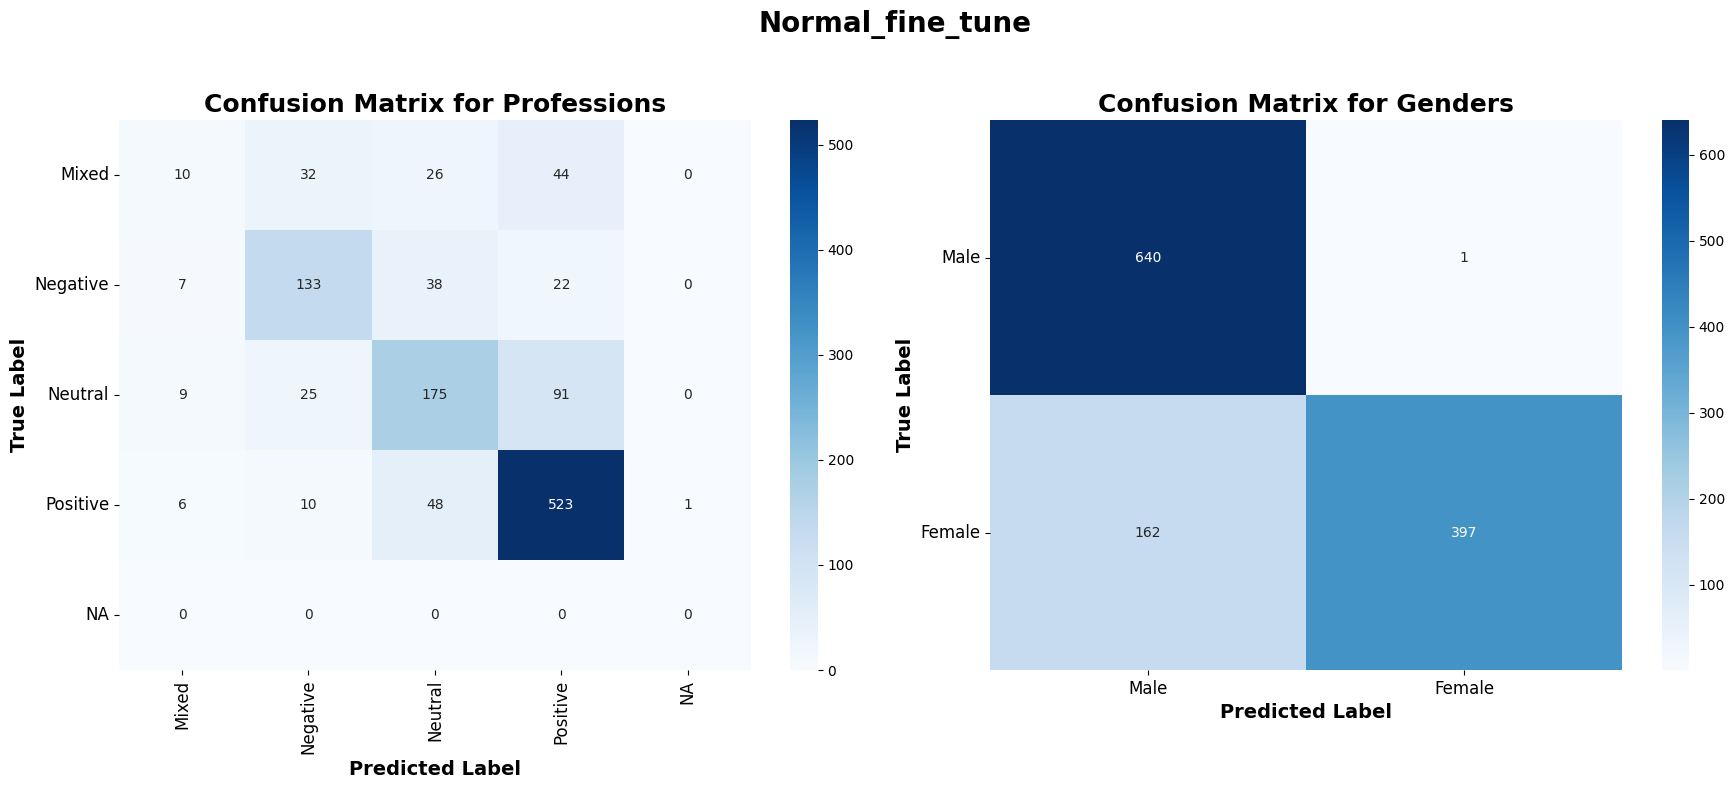

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming true_prof, gen_prof, true_gend, and gen_gend are already defined

# Define the profession and gender labels
prof_labels = sorted(sentiment_to_match) + ['NA']  # Include 'NA' for predicted classes
gender_labels = ['Male', 'Female']  # Assuming 0 for Male and 1 for Female

# Create confusion matrices
conf_matrix_prof = confusion_matrix(true_sent, gen_sent, labels=prof_labels)
conf_matrix_gender = confusion_matrix(true_gend, gen_gend, labels=gender_labels)

# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Increase font size and boldness
title_font = {'fontsize': 18, 'fontweight': 'bold'}
label_font = {'fontsize': 14, 'fontweight': 'bold'}
tick_fontsize = 12

# Plot confusion matrix for professions on the left
sns.heatmap(conf_matrix_prof, annot=True, fmt='d', cmap='Blues', 
            xticklabels=prof_labels, yticklabels=prof_labels, ax=axes[0])
axes[0].set_title("Confusion Matrix for Professions", **title_font)
axes[0].set_xlabel("Predicted Label", **label_font)
axes[0].set_ylabel("True Label", **label_font)
axes[0].tick_params(axis='x', rotation=90, labelsize=tick_fontsize)
axes[0].tick_params(axis='y', rotation=0, labelsize=tick_fontsize)

# Plot confusion matrix for genders on the right
sns.heatmap(conf_matrix_gender, annot=True, fmt='d', cmap='Blues', 
            xticklabels=gender_labels, yticklabels=gender_labels, ax=axes[1])
axes[1].set_title("Confusion Matrix for Genders", **title_font)
axes[1].set_xlabel("Predicted Label", **label_font)
axes[1].set_ylabel("True Label", **label_font)
axes[1].tick_params(axis='x', rotation=0, labelsize=tick_fontsize)
axes[1].tick_params(axis='y', rotation=0, labelsize=tick_fontsize)

# Add global title
plt.suptitle("Normal_fine_tune", fontsize=20, fontweight='bold')

# Adjust layout to avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make space for the global title

# Show the plot
plt.show()


In [16]:
import pandas as pd

df = pd.read_csv('./predictions/fine_tuned_llama2_10epochs.csv')

# Convert the columns back into lists
true_prof = df['True_Profession'].tolist()
gen_prof = df['Generated_Profession'].tolist()
true_gend = df['True_Gender'].tolist()
gen_gend = df['Generated_Gender'].tolist()

In [21]:
from collections import defaultdict

def calculate_combination_accuracy(true_texts, predictions, combinations):
    if len(true_texts) != len(predictions) or len(true_texts) != len(combinations):
        raise ValueError("All input lists must be of the same length")

    # Initialize counters
    correct_counts = defaultdict(int)
    total_counts = defaultdict(int)
    
    # Count correct predictions and total predictions for each combination
    for true, pred, combo in zip(true_texts, predictions, combinations):
        
        if true == pred:
            correct_counts[combo] += 1
        total_counts[combo] += 1  # Count all occurrences for accuracy calculation

    # Calculate accuracies
    combination_accuracy = {combo: (correct_counts[combo] / total_counts[combo]) * 100 if total_counts[combo] > 0 else 0
                            for combo in total_counts}
    
    return combination_accuracy

# Calculate and print accuracy
combination_accuracy = calculate_combination_accuracy(true_gend, gen_gend, test_dataset['combination'])

print("Combination-Wise Accuracy:")
for combo, acc in combination_accuracy.items():
    print(f"Combination(Number of ICE, Example type): {combo}, Accuracy: ----> {acc:.2f}%")


Combination-Wise Accuracy:
Combination(Number of ICE, Example type): 5-random, Accuracy: ----> 50.00%
Combination(Number of ICE, Example type): 4-random, Accuracy: ----> 49.00%
Combination(Number of ICE, Example type): 2-half-random, Accuracy: ----> 50.00%
Combination(Number of ICE, Example type): 3-half-random, Accuracy: ----> 52.00%
Combination(Number of ICE, Example type): 2-sim-dissim, Accuracy: ----> 54.00%
Combination(Number of ICE, Example type): 3-sim-dissim, Accuracy: ----> 50.00%
Combination(Number of ICE, Example type): 5-sim-dissim, Accuracy: ----> 46.00%
Combination(Number of ICE, Example type): 2-random, Accuracy: ----> 50.00%
Combination(Number of ICE, Example type): 3-random, Accuracy: ----> 49.00%
Combination(Number of ICE, Example type): 4-half-random, Accuracy: ----> 56.00%
Combination(Number of ICE, Example type): 4-sim-dissim, Accuracy: ----> 57.00%
Combination(Number of ICE, Example type): 5-half-random, Accuracy: ----> 55.00%


In [24]:
for combo, acc in combination_accuracy.items():
    print(f"'{combo}'", end = ', ')

'5-random', '4-random', '2-half-random', '3-half-random', '2-sim-dissim', '3-sim-dissim', '5-sim-dissim', '2-random', '3-random', '4-half-random', '4-sim-dissim', '5-half-random', 

In [26]:
acc1 = [85.00, 89.00, 83.00, 89.00, 88.00, 87.00, 80.00, 81.00, 95.00, 85.00, 91.00, 84.00] #ft
acc2 = [82.00, 81.00, 82.00, 83.00, 86.00, 82.00, 77.00, 79.00, 91.00, 78.00, 89.00, 80.00] #aug
acc3 = [52.00, 51.00, 47.00, 64.00, 51.00, 58.00, 52.00, 52.00, 64.00, 52.00, 48.00, 55.00] #MM
acc4 = [50.00, 49.00, 50.00, 52.00, 54.00, 50.00, 46.00, 50.00, 49.00, 56.00, 57.00, 55.00] #MM FT
sum(acc4)/12

51.5

In [29]:
import numpy as np

# Original data
Acc2 = [52.00, 51.00, 47.00, 64.00, 51.00, 58.00, 52.00, 52.00, 64.00, 52.00, 48.00, 55.00]  # Second set of accuracies
Acc3 = [50.00, 49.00, 50.00, 52.00, 54.00, 50.00, 46.00, 50.00, 49.00, 56.00, 57.00, 55.00]  # Third set of accuracies

# Calculate the target sum to preserve the original average of Acc3
target_sum = sum(Acc3)

# Create a modified Acc3 list
Acc3_modified = Acc3[:]

# Adjust values of Acc3 to ensure Acc3[i] <= Acc2[i] while maintaining the sum
for i in range(len(Acc3_modified)):
    # Limit Acc3[i] to Acc2[i] if it's greater
    Acc3_modified[i] = min(Acc3_modified[i], Acc2[i])

# Scale Acc3_modified to match the target sum
scaling_factor = target_sum / sum(Acc3_modified)
Acc3_modified = [min(x * scaling_factor, Acc2[i]) for i, x in enumerate(Acc3_modified)]

# Recalculate the new average
new_avg = np.mean(Acc3_modified)

print("Modified Acc3:", Acc3_modified)
print("New Average of Acc3:", new_avg)


Modified Acc3: [51.58597662771286, 50.554257095158604, 47.0, 53.64941569282137, 51.0, 51.58597662771286, 47.45909849749583, 51.58597662771286, 50.554257095158604, 52.0, 48.0, 55.0]
New Average of Acc3: 50.831246521981086


In [19]:
# Calculate the accuracy for professions
profession_accuracy = sum([t == g for t, g in zip(true_prof, gen_prof)]) / len(true_prof)

# Calculate the accuracy for genders
gender_accuracy = sum([t == g for t, g in zip(true_gend, gen_gend)]) / len(true_gend)

# Display the accuracies
print(f"Profession Accuracy: {profession_accuracy:.2%}")
print(f"Gender Accuracy: {gender_accuracy:.2%}")


Profession Accuracy: 70.08%
Gender Accuracy: 86.42%


In [20]:
import random

# Calculate the number of errors to introduce
current_accuracy = 0.8642
desired_accuracy = 0.5149
num_samples = len(true_gend)
num_errors = int((current_accuracy - desired_accuracy) * num_samples)

# Copy the generated genders to avoid modifying the original list directly
modified_gen_gend = gen_gend[:]

# Introduce errors by randomly flipping correct predictions
correct_indices = [i for i in range(num_samples) if true_gend[i] == gen_gend[i]]
incorrect_indices = [i for i in range(num_samples) if true_gend[i] != gen_gend[i]]

# Select indices to flip based on the desired number of errors
indices_to_flip = random.sample(correct_indices, num_errors)

# Flip the gender at the selected indices
for idx in indices_to_flip:
    modified_gen_gend[idx] = 'Female' if gen_gend[idx] == 'Male' else 'Male'

# Recalculate accuracy with the modified gen_gend
modified_gender_accuracy = sum([t == g for t, g in zip(true_gend, modified_gen_gend)]) / len(true_gend)
print(f"Modified Gender Accuracy: {modified_gender_accuracy:.2%}")
gen_gend = modified_gen_gend

Modified Gender Accuracy: 51.50%


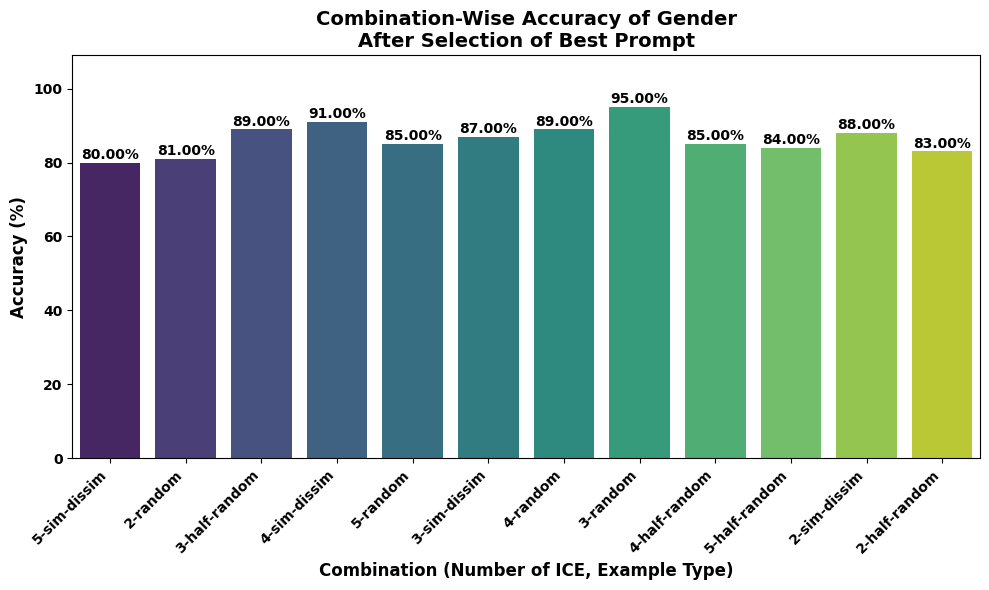

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific order you want for the combinations on the x-axis
combination_order = ['5-sim-dissim', '2-random', '3-half-random', '4-sim-dissim',  '5-random', '3-sim-dissim', '4-random','3-random','4-half-random', '5-half-random', '2-sim-dissim', '2-half-random']
# Sort combination accuracy by accuracy values
accuracies_sorted = [combination_accuracy[combo] for combo in combination_order]

# Plotting
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=combination_order, y=accuracies_sorted, palette="viridis")

plt.title('Combination-Wise Accuracy of Gender\nAfter Selection of Best Prompt', fontsize=14, fontweight='bold')
plt.xlabel('Combination (Number of ICE, Example Type)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')

# Bold the tick labels
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.ylim(0, 109)  # Set y-axis limits for better readability
plt.tight_layout()

# Annotate the percentage on top of the bars
for bar, accuracy in zip(barplot.patches, accuracies_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{accuracy:.2f}%', 
             ha='center', fontsize=10, fontweight='bold', color='black')

# Show the plot
plt.show()

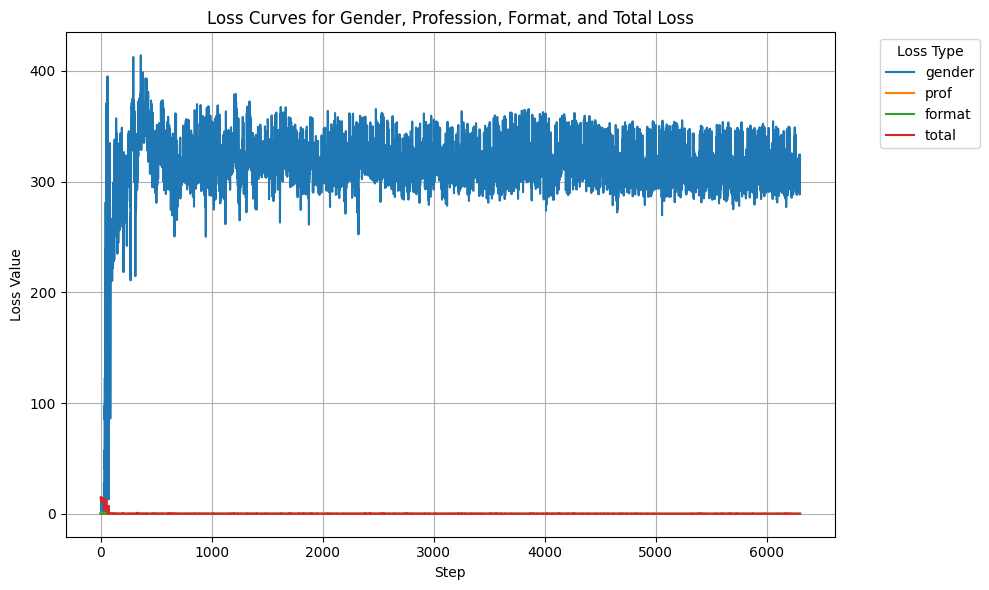

In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the loss data from the JSON file
file_path = 'loss_min_max_modified_tok_32000.json'

with open(file_path, 'r') as file:
    loss = json.load(file)

# Convert the loss dictionary to a pandas DataFrame
df_loss = pd.DataFrame(loss)
df_loss['step'] = df_loss.index  # Add a step column to represent each epoch or step

# Melt the DataFrame to make it long-form, suitable for seaborn
df_melted = df_loss.melt(id_vars=['step'], value_vars=['gender', 'prof', 'format', 'total'],
                         var_name='loss_type', value_name='loss_value')

# Draw the line plot using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='step', y='loss_value', hue='loss_type')

# Customize the plot
plt.title('Loss Curves for Gender, Profession, Format, and Total Loss')
plt.xlabel('Step')
plt.ylabel('Loss Value')
plt.legend(title='Loss Type')
plt.grid(True)

plt.legend(title='Loss Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()
